In [1]:
import os
# feiura
try:
    ORIGINAL # type: ignore
except NameError:
    ORIGINAL = os.getcwd()
    if ORIGINAL.strip("/").endswith("scenarios/test"):
        os.chdir("../../")

In [2]:
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm

import easyvvuq as uq

/home/machado/energyuq/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/machado/energyuq/.venv/lib/python3.14/site-packages/chaospy/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources


In [3]:
def verify_adaptation_integrity(analysis, sampler, qoi="qoi_out", df_last=None):
    """
    Validates structural correctness and numerical stability after 100+ iterations.
    """
    report = {}
    
    # Check 1: Multi-index duplicate validation
    # l_norm should not contain duplicated rows
    unique_indices = np.unique(analysis.l_norm, axis=0)
    report["l_norm_duplicates_found"] = len(analysis.l_norm) - len(unique_indices)
    
    # Check 2: NaNs / Infs in error or statistics histories
    errs = np.array(analysis.adaptation_errors)
    means = np.array(analysis.mean_history)
    stds = np.array(analysis.std_history)
    
    report["nan_in_adaptation_errors"] = bool(np.isnan(errs).any())
    report["inf_in_adaptation_errors"] = bool(np.isinf(errs).any())
    report["nan_in_mean_history"] = bool(np.isnan(means).any())
    report["nan_in_std_history"] = bool(np.isnan(stds).any())
    
    # Check 3: Combination technique conservation
    # Sum of combination coefficients across all accepted sub-grids should equal 1.0
    comb_sum = sum(analysis.comb_coef[tuple(k)] for k in analysis.l_norm)
    report["comb_coef_sum"] = float(comb_sum)
    report["comb_coef_valid"] = bool(np.isclose(comb_sum, 1.0, atol=1e-5))
    
    # Check 4: Test interpolation accuracy on collocation grid
    if df_last is not None:
        pts = sampler.xi_d
        y_true = df_last[qoi].values
        y_surr = np.array([analysis.surrogate(qoi, pt) for pt in pts])
        report["max_collocation_interpolation_error"] = float(np.max(np.abs(y_true - y_surr)))
        
    print("--- ADAPTATION INTEGRITY REPORT ---")
    for k, v in report.items():
        status = "PASSED" if (v is False or v == 0 or v is True) else "FLAGGED"
        print(f"{k:<40}: {v} [{status}]")
        
    return report

In [4]:
from typing import Any
import chaospy as cp

params_type = dict[str, dict[str, Any]]
vary_type = dict[str, cp.Distribution]

params: params_type = {}
vary: vary_type = {}

vary = {
    "N_THREADS": cp.DiscreteUniform(1, 48),
    "CLK": cp.DiscreteUniform(0, 11),
    "PLACE_WIDE": cp.DiscreteUniform(0, 4),
    "AFF_DISTANCE": cp.DiscreteUniform(0, 4),
    "BOOST": cp.DiscreteUniform(0, 1),
}

# All parameters defined for the application with their default values
params["N_THREADS"] = {"type": "integer", "default": 32}
params["CLK"] = {"type": "integer", "default": 4}
params["PLACE_WIDE"] = {"type": "integer", "default": 4}
params["AFF_DISTANCE"] = {"type": "integer", "default": 3}
params["BOOST"] = {"type": "integer", "default": 1}

/home/machado/energyuq/.venv/lib/python3.14/site-packages/cerberus/validator.py:618: UserWarning: These types are defined both with a method and in the'types_mapping' property of this validator: {'integer'}
  warn(
/home/machado/energyuq/.venv/lib/python3.14/site-packages/cerberus/validator.py:618: UserWarning: These types are defined both with a method and in the'types_mapping' property of this validator: {'integer'}
  warn(
100%|██████████| 1/1 [00:00<00:00, 751.94it/s]


Adapt because too few runs
-------2nd iteration-------
-------9 new points------
-------Executed 9 in total-------


100%|██████████| 9/9 [00:00<00:00, 2901.74it/s]


Adapt because too few runs
-------3rd iteration-------
-------0 new points------
-------Executed 9 in total-------


0it [00:00, ?it/s]


...

Adapt because min_number_of_refinements
-------101st iteration-------
-------0 new points------
-------Executed 457 in total-------


0it [00:00, ?it/s]


Iteration 100 | Surplus: 0.000e+00 (Pass[[167547.96010033]]: [ True]) | Rel Mean Δ: 0.000e+00 | Rel Var Δ: 0.000e+00 | Consecutive Stable: 1/2
Adapt because it has not converged yet [0.0, 6022.515332867624, 0.0]
-------102nd iteration-------
-------8 new points------
-------Executed 465 in total-------


100%|██████████| 8/8 [00:00<00:00, 3259.61it/s]


Converged [[1681409.76321568]]: [6022.515332867624, 0.0, 5930.16221237788]
--- ADAPTATION INTEGRITY REPORT ---
l_norm_duplicates_found                 : 0 [PASSED]
nan_in_adaptation_errors                : False [PASSED]
inf_in_adaptation_errors                : False [PASSED]
nan_in_mean_history                     : False [PASSED]
nan_in_std_history                      : False [PASSED]
comb_coef_sum                           : 1.0 [FLAGGED]
comb_coef_valid                         : True [PASSED]
max_collocation_interpolation_error     : 9.094947017729282e-13 [FLAGGED]


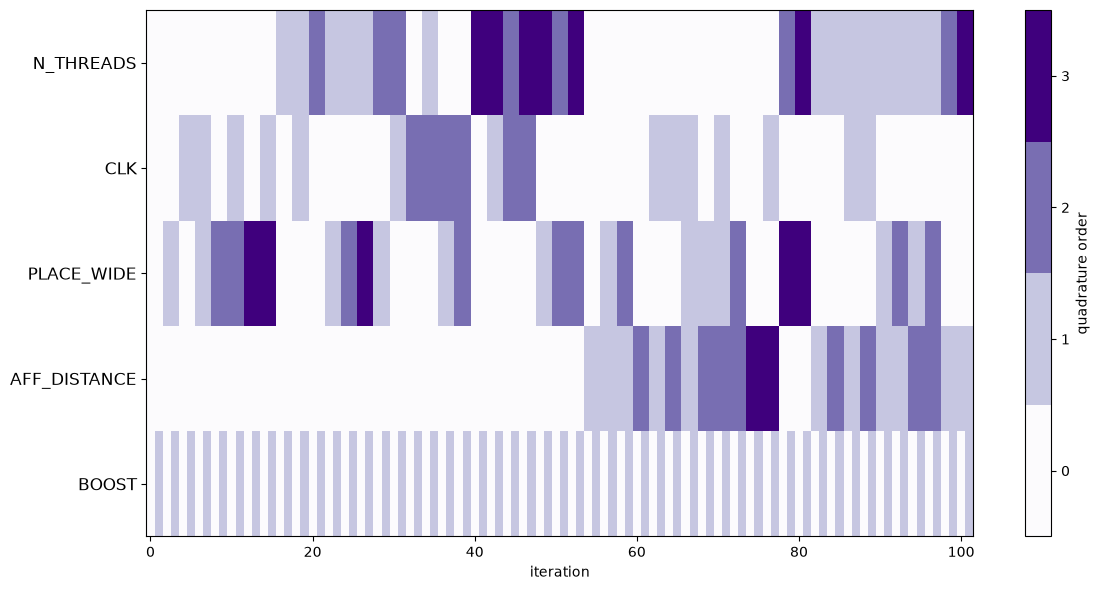

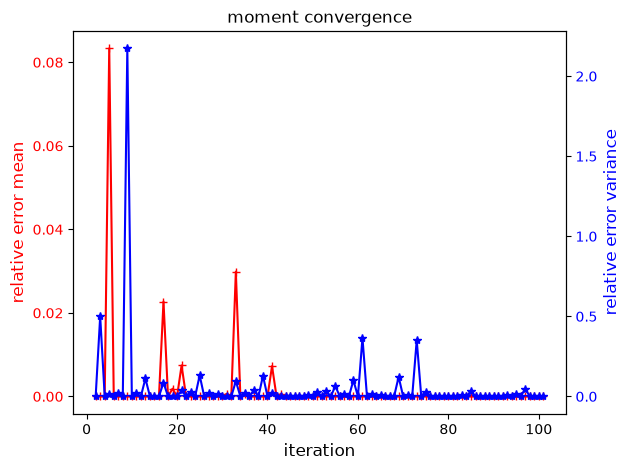

In [5]:
# --- Jupyter Cell: Execution ---
from pathlib import Path
from uuid import uuid4

from easyvvuq.analysis.sc_analysis import SCAnalysis
from easyvvuq.sampling import SCSampler

from src import energyuq

target_qoi = "energy_uj"
def TRUEmodel(args):
    return {target_qoi:(
        (args["N_THREADS"]) *
        args["AFF_DISTANCE"] *
        args["CLK"] *
        args["PLACE_WIDE"] *
        args["BOOST"]
    )}
path = Path(f"/tmp/{uuid4()}")
path.mkdir(exist_ok=True)

campaign = uq.Campaign(
    name="energy",
    db_location="sqlite:///" + path.as_posix() + "/campaign.db",
    work_dir=path.as_posix(),
)
campaign.add_app(name=campaign.campaign_name, params=params, actions=uq.actions.Actions(
    uq.actions.ExecutePython(TRUEmodel)
))
sampler = SCSampler(
    vary=vary,
    polynomial_order=1,
    quadrature_rule="C",
    sparse=True,
    midpoint_level1=True,
    dimension_adaptive=True,
)
campaign.set_sampler(sampler)

analysis = SCAnalysis(
    sampler=sampler, qoi_cols=[target_qoi]
)

if not hasattr(analysis, "l_norm"):
    analysis.l_norm = sampler.l_norm

campaign.execute(sequential=True).collate(progress_bar=True)
campaign.apply_analysis(analysis)

energyuq.refine_and_analyse(campaign, analysis, min_number_of_refinements=100, max_number_of_refinements=200)

verify_adaptation_integrity(analysis, sampler, qoi=target_qoi, df_last=campaign.get_collation_result())

# 5. Native Visualizations from SCAnalysis
analysis.adaptation_table()
analysis.plot_stat_convergence()